# Geração de Curvas de Carga (Load Shapes) para OpenDSS

**Projeto:** Análise de Fluxo de Carga Temporal (IEEE 13 Bus)
**Contexto:** Preparação de dados para simulação QSTS (Quasi-Static Time Series).

### Objetivo
Este notebook tem como objetivo processar dados brutos de medição de energia (arquivos CSV) para gerar curvas de carga diárias normalizadas (p.u.). Estas curvas serão utilizadas para modelar o comportamento temporal das cargas no circuito **IEEE 13 Node Test Feeder** dentro do OpenDSS.

### Metodologia
1.  **Conexão:** Carregamento do circuito no OpenDSS para identificar as cargas existentes.
2.  **Processamento Robusto:** Leitura de dados reais, filtragem de dias com falhas e seleção de dias válidos.
3.  **Normalização:** Conversão para *per unit* (p.u.) e reamostragem para passos de 5 minutos (288 pontos/dia).
4.  **Exportação:** Gravação dos resultados em CSV estruturado.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from opendssdirect import dss
from pathlib import Path
import os

## 1. Configuração do Ambiente e Caminhos

Importação das bibliotecas necessárias e definição robusta dos diretórios do projeto. Utilizamos a biblioteca `pathlib` para garantir compatibilidade entre sistemas operacionais (Windows/Linux) e caminhos relativos, assegurando que o código funcione independentemente de onde a pasta do projeto esteja salva.

In [26]:
# --- DEFINIÇÃO DE CAMINHOS ROBUSTA ---
# 1. Identifica a pasta onde o notebook está rodando e sobe um nível ("..") para a raiz do projeto
# .resolve() elimina ambiguidades como ".." e retorna o caminho absoluto completo
PROJECT_ROOT = Path("..").resolve() 

# 2. Define o caminho para a pasta de dados (CSV)
BASE_DIR = PROJECT_ROOT / "data"

# 3. Define o caminho para o arquivo .dss
# Estrutura: raiz -> data -> 13Bus -> IEEE13Nodeckt.dss
DSS_FILE = BASE_DIR / "13Bus" / "IEEE13Nodeckt.dss"

## 2. Inicialização do Circuito (OpenDSS)

Nesta etapa, carregamos o arquivo mestre do circuito (`IEEE13Nodeckt.dss`) para extrair programaticamente os nomes das cargas (`Load.671`, `Load.634a`, etc.). Isso garante que geraremos curvas apenas para os elementos que realmente compõem o modelo elétrico.

In [ ]:
# --- INICIALIZAÇÃO DO OPENDSS ---
try:
    if not DSS_FILE.exists():
        raise FileNotFoundError(f"Arquivo DSS não encontrado em: {DSS_FILE}")

    dss.Command("Clear")
    # É crucial converter para string e usar resolve() para o OpenDSS entender o caminho
    dss.Command(f"redirect '{str(DSS_FILE.resolve())}'")
    dss.Command('Solve')
    
    loads = dss.Loads.AllNames()
    print(f"Sucesso! Cargas encontradas via OpenDSS: {len(loads)}")
    print(f"Cargas: {loads}")
    
except Exception as e:
    print(f"\n[ERRO] Não foi possível carregar o OpenDSS.")

## 3. Configuração da Fonte de Dados

Definimos qual arquivo CSV contém os dados brutos de medição (Smart Meter data). Mapeamos cada carga do OpenDSS para este arquivo fonte.

In [17]:
config_elements = {}
source_file = BASE_DIR / "nextgen-energy-raw" / "90-id_261.csv"

# Data inicial
start_date = pd.Timestamp('2018-01-04')

for i, load in enumerate(loads):
    # Incrementa a data automaticamente
    current_date = start_date + pd.Timedelta(days=i)
    
    config_elements[f'Load.{load}'] = {
        'file': source_file,
        'type': 'load',
        'column': 'load power (kW)',
        'time-step': 300,        # 5 minutos
        'date': current_date.strftime('%Y-%m-%d') # Formata automaticamente para AAAA-MM-DD
    }

# Mostra um exemplo para verificar
print(f"Exemplo de configuração para Load.{loads[0]}:")
print(config_elements[f'Load.{loads[0]}'])

Exemplo de configuração para Load.671:
{'file': WindowsPath('D:/UFC/2-MESTRADO/1-semestre/ESTUDOS ESPECIAIS EM ENGENHARIA ELETRICA II (THP7244)/lucas/trabalho-final/projeto/THP7244-final-project/data/nextgen-energy-raw/90-id_261.csv'), 'type': 'load', 'column': 'load power (kW)', 'time-step': 300, 'date': '2018-01-04'}


## 4. Algoritmo de Extração e Normalização (Robusto)

A função abaixo implementa a lógica central de processamento de dados, inspirada em técnicas de EDA (Análise Exploratória de Dados).

**Lógica do Algoritmo:**
1.  **Leitura Eficiente:** Lê o arquivo CSV completo de uma vez.
2.  **Alinhamento Temporal:** Cria uma coluna auxiliar (`Time_Plot`) normalizando todas as datas para um "dia fictício" (01/01/2000), permitindo sobrepor e alinhar curvas de dias diferentes.
3.  **Filtragem de Qualidade:** Verifica quantos pontos de medição existem em cada dia. Dias com muitos dados faltantes são descartados.
4.  **Distribuição Cíclica:** Os "dias bons" encontrados são distribuídos sequencialmente entre as cargas do sistema.
5.  **Tratamento de Lacunas:** Utiliza interpolação linear para preencher pequenos buracos nos dados e `reindex` para garantir exatamente 288 pontos (passo de 5 min).
6.  **Cálculo p.u.:** Divide a curva pelo seu valor de pico diário.

In [27]:
def build_robust_load_curves(config_dict, loads_list):
    """
    Gera curvas de carga usando apenas dias VÁLIDOS encontrados no arquivo CSV.
    Inspirado na abordagem de 'Time_Plot' do notebook de EDA.
    """
    # 1. Identificar o arquivo fonte (assumindo que todas usam o mesmo arquivo base, como no seu exemplo)
    # Pega o arquivo da primeira carga como referência
    first_load_config = config_dict[f'Load.{loads_list[0]}']
    source_file = first_load_config['file']
    target_col = first_load_config['column']
    
    print(f"Lendo arquivo fonte: {source_file.name}...")
    
    # --- ABORDAGEM TIPO EDA ---
    # Lê tudo de uma vez
    df_raw = pd.read_csv(source_file)
    
    # Identifica coluna de tempo (1ª coluna) e converte
    time_col = df_raw.columns[0]
    df_raw[time_col] = pd.to_datetime(df_raw[time_col], unit='s')
    
    # Cria colunas auxiliares de Data e Tempo Normalizado (Time_Plot)
    # Isso é exatamente como o notebook EDA faz para alinhar curvas
    base_date = pd.Timestamp('2000-01-01')
    
    df_raw['Date'] = df_raw[time_col].dt.date
    df_raw['Time_Plot'] = df_raw[time_col].apply(
        lambda x: x.replace(year=base_date.year, month=base_date.month, day=base_date.day)
    )
    
    # --- SELEÇÃO DE DIAS VÁLIDOS ---
    # Conta quantos pontos existem por dia
    daily_counts = df_raw.groupby('Date')[target_col].count()
    
    # Filtra apenas dias que estão "quase completos" (ex: > 200 pontos de 5min, num total de 288)
    # Isso evita pegar dias com meio dado que gerariam curvas feias
    valid_dates = daily_counts[daily_counts > 250].index.tolist()
    valid_dates.sort()
    
    print(f"Dias válidos encontrados no arquivo: {len(valid_dates)}")
    if len(valid_dates) < len(loads_list):
        print(f"⚠️ AVISO: Temos apenas {len(valid_dates)} dias bons para {len(loads_list)} cargas.")
        print("Alguns dias serão repetidos para preencher.")
        # Repete a lista de dias para cobrir todas as cargas se necessário
        valid_dates = valid_dates * (len(loads_list) // len(valid_dates) + 1)
    
    # --- CONSTRUÇÃO DAS CURVAS ---
    series_list = []
    metadata = {}
    
    # Grid de tempo padrão (24h de 5 em 5 min)
    full_day_index = pd.date_range(start="2000-01-01 00:00:00", periods=288, freq='300s')
    
    for i, load_name in enumerate(loads_list):
        # Pega um dia válido da lista (ciclíco)
        selected_date = valid_dates[i]
        load_id = f"Load.{load_name}"
        
        # Filtra os dados desse dia específico
        mask = df_raw['Date'] == selected_date
        df_day = df_raw.loc[mask].copy()
        
        # Prepara a série usando o Time_Plot como índice para alinhar
        df_day.set_index('Time_Plot', inplace=True)
        
        # Remove duplicatas de índice se houver (segurança)
        df_day = df_day[~df_day.index.duplicated(keep='first')]
        
        # Reindexa para o grid perfeito de 288 pontos
        series_clean = df_day[target_col].reindex(full_day_index, method='nearest', tolerance=pd.Timedelta('10min'))
        
        # Interpolação para preencher pequenos buracos (como no EDA plot)
        series_clean = series_clean.interpolate(method='linear').fillna(0)
        
        # Normalização (p.u.)
        peak = series_clean.max()
        if peak == 0: peak = 1.0
        
        series_pu = series_clean / peak
        series_pu.name = load_id
        
        series_list.append(series_pu)
        metadata[load_id] = {'source_date': str(selected_date), 'peak_kw': peak}

    # Consolida tudo
    df_final = pd.concat(series_list, axis=1)
    return df_final, metadata


### Execução do Processamento

Rodamos a função definida acima. O resultado será um DataFrame `df_curves` onde cada coluna representa o perfil diário de uma carga do sistema IEEE 13 Bus, sem valores nulos ou zerados indevidamente.

In [29]:
# --- EXECUÇÃO ---
# Nota: Não precisamos mais daquele loop complexo de datas no 'config_elements'.
# Basta passar a lista de cargas e a configuração básica de arquivo.

df_curves, meta = build_robust_load_curves(config_elements, loads)

print("\nPrimeiras linhas do resultado:")
# print(df_curves.head())
display(df_curves.head())

# Verifica se ainda tem zeros totais
sums = df_curves.sum()
zeros = sums[sums == 0]
if not zeros.empty:
    print("Ainda há curvas zeradas:", zeros.index.tolist())
else:
    print("Sucesso! Todas as curvas têm dados.")

Lendo arquivo fonte: 90-id_261.csv...
Dias válidos encontrados no arquivo: 349

Primeiras linhas do resultado:


,Load.671,Load.634a,Load.634b,Load.634c,Load.645,Load.646,Load.692,Load.675a,Load.675b,Load.675c,Load.611,Load.652,Load.670a,Load.670b,Load.670c
2000-01-01 00:00:00,0.848013,0.748686,0.705199,0.807253,0.750314,0.736149,0.807966,0.600800,0.908642,0.733714,0.797055,0.806446,0.784840,0.815829,0.852366
2000-01-01 00:05:00,0.849223,0.730222,0.718679,0.808851,0.741444,0.740960,0.807459,0.607763,0.895434,0.739927,0.796825,0.810092,0.785417,0.815331,0.854029
2000-01-01 00:10:00,0.848982,0.691923,0.709871,0.810404,0.739910,0.742337,0.807822,0.610465,0.898581,0.739817,0.792655,0.797665,0.789896,0.811007,0.855608
2000-01-01 00:15:00,0.847831,0.767877,0.705819,0.810689,0.741126,0.740784,0.807895,0.608169,0.896355,0.732078,0.794701,0.800795,0.790342,0.808565,0.864678
2000-01-01 00:20:00,0.938217,0.815136,0.700286,0.820009,0.741922,0.736520,0.851761,0.612961,0.887000,0.732817,0.824645,0.804624,0.790409,0.808671,0.930207


Sucesso! Todas as curvas têm dados.


## 5. Visualização dos Resultados (Sanity Check)

Antes de exportar, verificamos visualmente a consistência dos dados.
* **Linhas Coloridas:** Perfis individuais de cada carga.
* **Linha Preta Tracejada:** O perfil médio do sistema.

O gráfico confirma se a normalização ocorreu corretamente e se os picos de consumo estão nos horários esperados.

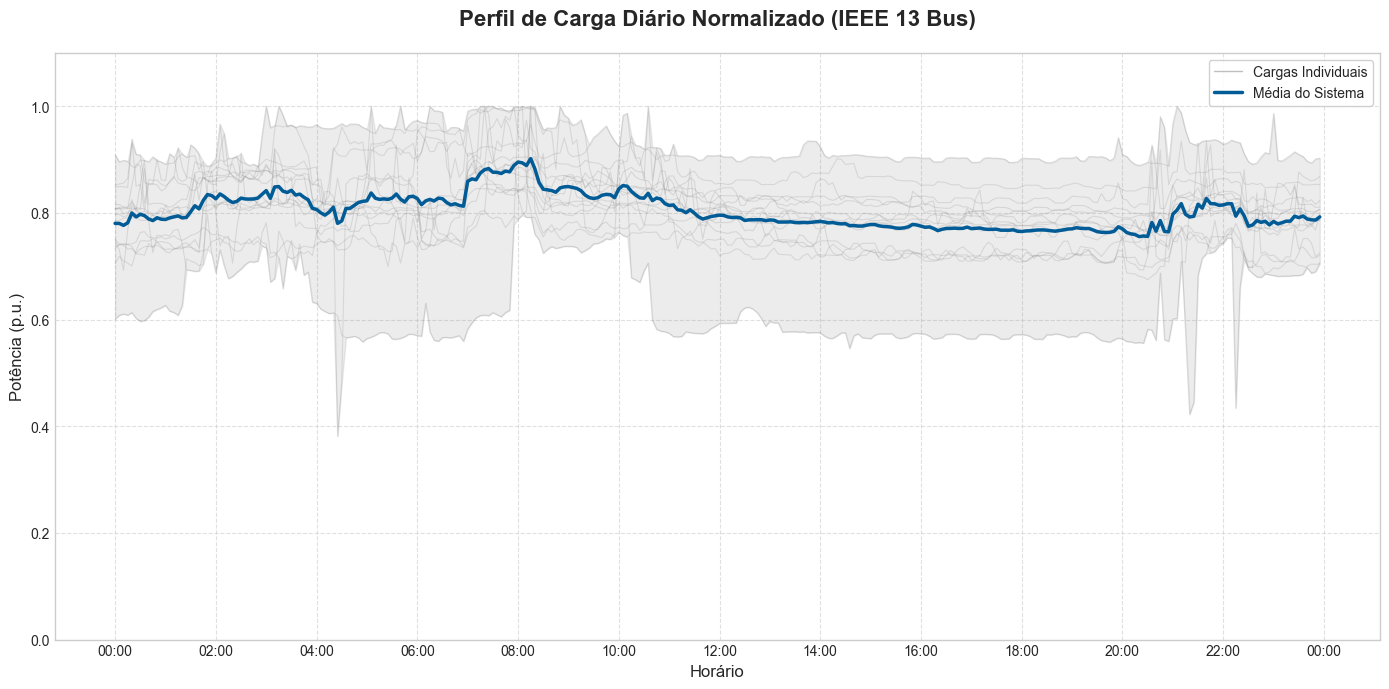

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

if not df_curves.empty:
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # 1. Plota a sombra de Mínimo e Máximo (Faixa de Operação)
    ax.fill_between(df_curves.index, 
                    df_curves.min(axis=1), 
                    df_curves.max(axis=1), 
                    color='gray', alpha=0.15, label='Faixa (Min-Max)')
    
    # 2. Plota todas as curvas individuais em cinza discreto
    # label='_nolegend_' evita que elas poluam a legenda
    ax.plot(df_curves.index, df_curves.values, color='gray', alpha=0.2, linewidth=0.8)
    
    # 3. Plota a Média em destaque (Cor forte)
    mean_curve = df_curves.mean(axis=1)
    ax.plot(df_curves.index, mean_curve, color='#005b96', linewidth=2.5, label='Média do Sistema')
    
    # --- Estética ---
    ax.set_title('Perfil de Carga Diário Normalizado (IEEE 13 Bus)', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Horário', fontsize=12)
    ax.set_ylabel('Potência (p.u.)', fontsize=12)
    
    # Formatação do Eixo X (Horas)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2)) # Marca a cada 2 horas
    
    # Limites e Grid
    ax.set_ylim(0, 1.1) # Garante que vai de 0 a um pouco acima de 1
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Legenda Limpa (Apenas Média e Faixa)
    # Criamos uma linha falsa cinza apenas para constar na legenda como "Cargas Individuais"
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='gray', lw=1, alpha=0.5),
                    Line2D([0], [0], color='#005b96', lw=2.5)]
    ax.legend(custom_lines, ['Cargas Individuais', 'Média do Sistema'], loc='upper right', frameon=True, fancybox=True, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

else:
    print("Sem dados para plotar.")

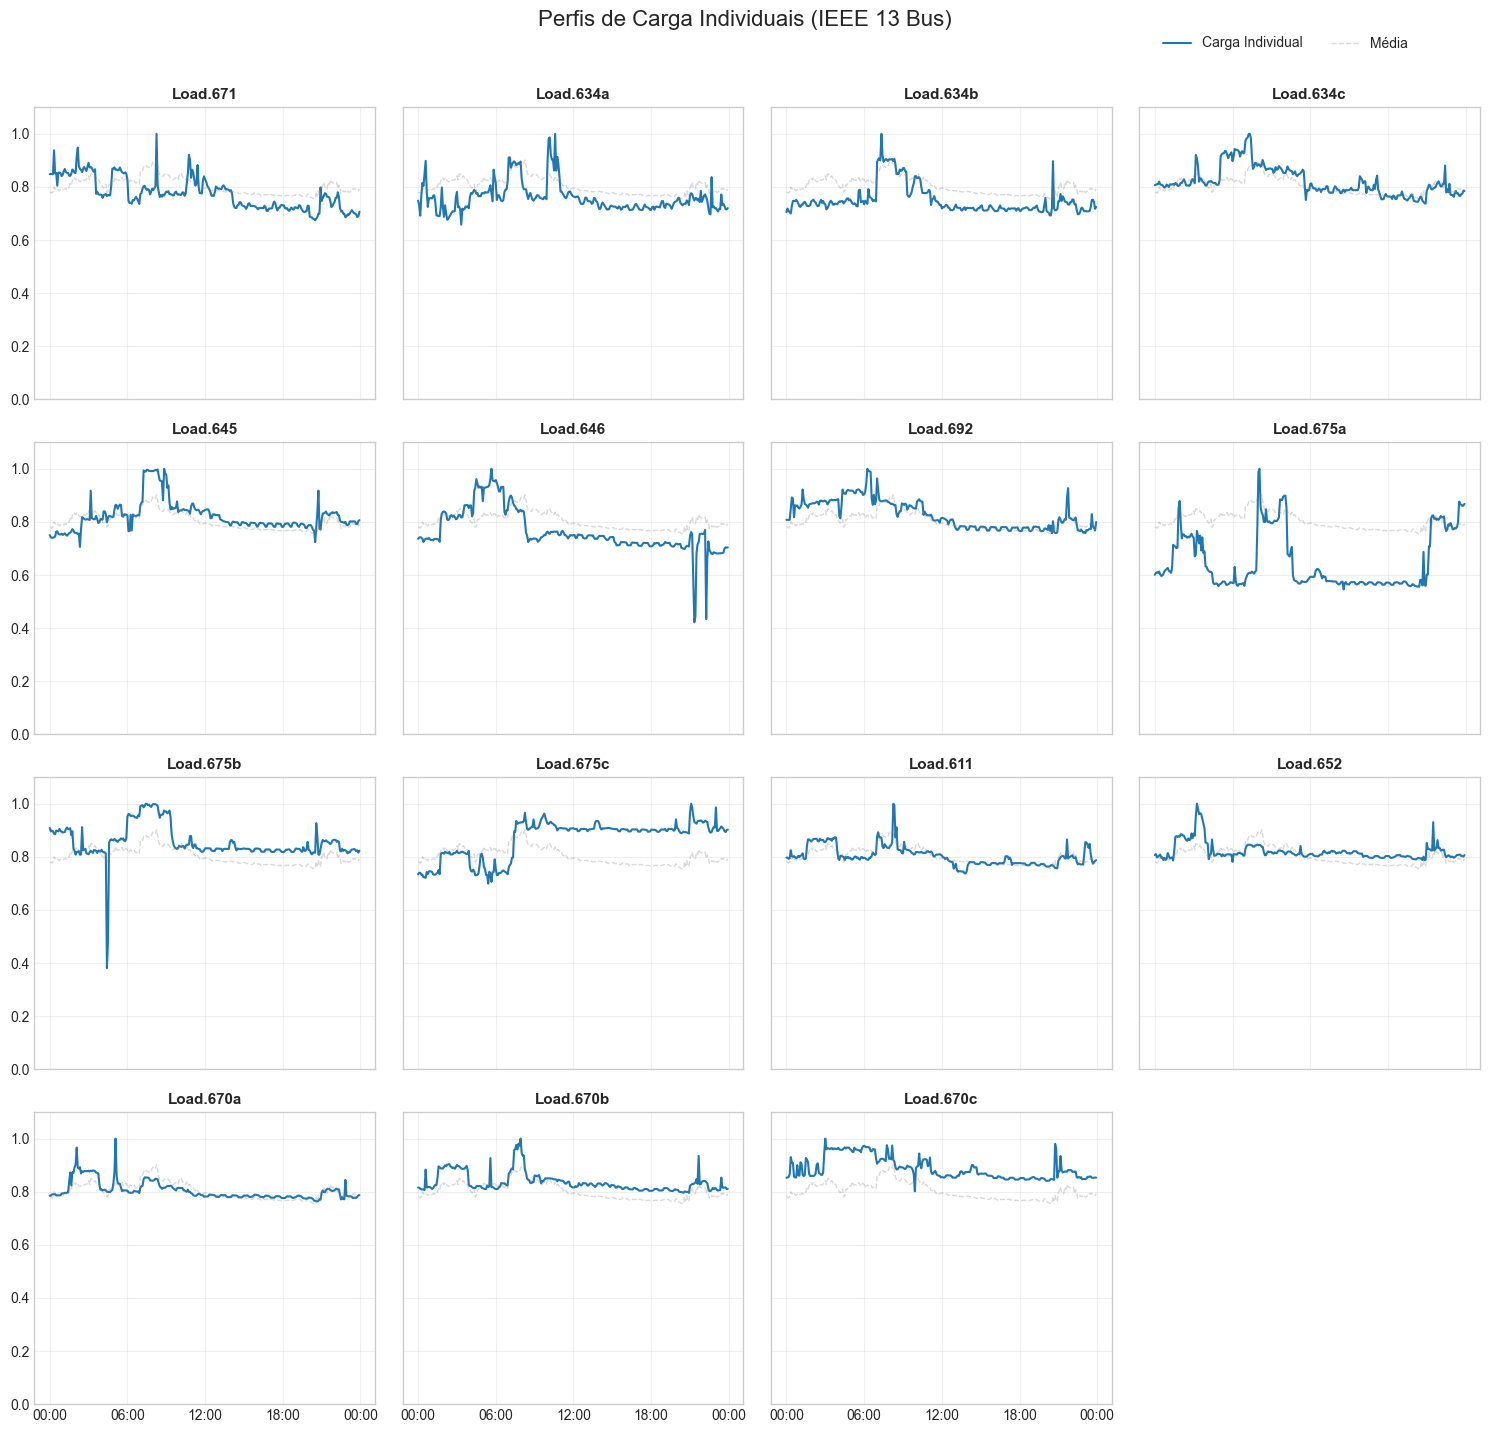

In [38]:
import math

if not df_curves.empty:
    # 1. Configuração do Grid
    num_plots = len(df_curves.columns)
    cols = 4  # Vamos usar 4 colunas (pode ajustar para 3 ou 5 se preferir)
    rows = math.ceil(num_plots / cols) # Calcula linhas necessárias automaticamente
    
    # Tamanho da figura: Largura fixa, altura cresce conforme o número de linhas
    # (3.5 polegadas por subplot dá um aspecto quadrado bom)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows), sharex=True, sharey=True)
    axes = axes.flatten() # Transforma a matriz de eixos em uma lista linear para facilitar o loop

    # 2. Loop para plotar cada carga
    for i, col_name in enumerate(df_curves.columns):
        ax = axes[i]
        
        # Plota a curva da carga específica
        ax.plot(df_curves.index, df_curves[col_name], color='tab:blue', linewidth=1.5)
        
        # Plota a média do sistema ao fundo (em cinza claro) para referência/comparação
        mean_curve = df_curves.mean(axis=1)
        ax.plot(df_curves.index, mean_curve, color='gray', alpha=0.3, linestyle='--', linewidth=1, label='Média')
        
        # Estética do subplot
        ax.set_title(col_name, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.1)
        
        # Formatação de Hora (apenas nos gráficos de baixo, devido ao sharex=True)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        
        # Marcações de ticks (opcional: a cada 6h para não poluir)
        ax.set_xticks(pd.date_range(start="2000-01-01 00:00:00", periods=5, freq='6h'))

    # 3. Limpeza dos eixos vazios (se sobraram quadros no grid)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Títulos e Ajustes Finais
    fig.suptitle('Perfis de Carga Individuais (IEEE 13 Bus)', fontsize=16, y=1.02)
    
    # Legenda global (apenas uma para não repetir em todos)
    handles, labels = axes[0].get_legend_handles_labels()
    # Adiciona a linha azul manualmente na legenda
    from matplotlib.lines import Line2D
    handles.insert(0, Line2D([0], [0], color='tab:blue', lw=1.5))
    labels.insert(0, 'Carga Individual')
    
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.95, 1.01), ncol=2)
    
    plt.tight_layout()
    plt.show()

else:
    print("Sem dados para plotar.")

## 6. Exportação dos Dados

Salvameos o DataFrame processado na pasta `../data/curves/`. Este arquivo CSV (`13BUS_curve.csv`) servirá como entrada para criar os objetos `LoadShape` no OpenDSS para a simulação temporal.

In [25]:
# 1. Constrói o caminho completo
# BASE_DIR já é ".../data", então adicionamos "curves" e o nome do arquivo
output_path = BASE_DIR / "curves" / "13BUS_curve.csv"

# 2. Garante que a pasta 'curves' exista
# parents=True cria pastas pai se necessário (ex: data/curves)
# exist_ok=True não dá erro se a pasta já existir
output_path.parent.mkdir(parents=True, exist_ok=True)

# 3. Salva o arquivo
df_curves.to_csv(output_path, index_label='timestamp')